In [23]:
# ─────────────────────────────────────────────────────────────
# STEP 3 — DATA CLEANING
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("STEP 3 — DATA CLEANING")
print("=" * 60)

# Work on a copy — never modify the raw data
df = pd.read_csv("D:\\home-credit-default-risk\\data\\raw\\application_train.csv")
df_clean = df.copy()
original_shape = df_clean.shape
print(f"\n  Starting shape: {original_shape[0]:,} rows × {original_shape[1]} cols")

STEP 3 — DATA CLEANING

  Starting shape: 307,511 rows × 122 cols


In [7]:
df_clean.duplicated().sum()

np.int64(0)

In [24]:
# ─────────────────────────────────────────────────────────────
# 3A. DROP ROWS WITH XNA IN GENDER (only 4 rows — safe to drop)
# ─────────────────────────────────────────────────────────────

print("\n[3A] DROPPING XNA GENDER ROWS")
print("-" * 40)

before = len(df_clean)
df_clean = df_clean[df_clean["CODE_GENDER"] != "XNA"]
after = len(df_clean)
print(f"  Rows dropped : {before - after}")
print(f"  Rows remaining : {after:,}")



[3A] DROPPING XNA GENDER ROWS
----------------------------------------
  Rows dropped : 4
  Rows remaining : 307,507


In [25]:
# ─────────────────────────────────────────────────────────────
# 3B. FIX DAYS_EMPLOYED ANOMALY
# WHY: 365243 is a placeholder for unemployed/retired.
#      If we leave it, the model thinks these people have
#      been employed for 1000 years — completely wrong signal.
# ─────────────────────────────────────────────────────────────

print("\n[3B] FIXING DAYS_EMPLOYED ANOMALY")
print("-" * 40)

anomaly_count = (df_clean["DAYS_EMPLOYED"] == 365243).sum()
df_clean["DAYS_EMPLOYED"] = df_clean["DAYS_EMPLOYED"].replace(365243, np.nan)
print(f"  Replaced {anomaly_count:,} anomalous values with NaN")
print(f"  These will be handled by median imputation in 3D")


[3B] FIXING DAYS_EMPLOYED ANOMALY
----------------------------------------
  Replaced 55,374 anomalous values with NaN
  These will be handled by median imputation in 3D


In [26]:
# ─────────────────────────────────────────────────────────────
# 3C. CONVERT DAYS TO POSITIVE / MEANINGFUL UNITS
# WHY: Negative days are confusing. Age in years is
#      interpretable and consistent with business language.
# ─────────────────────────────────────────────────────────────

print("\n[3C] CONVERTING DAY COLUMNS TO YEARS (POSITIVE)")
print("-" * 40)

day_cols = {
    "DAYS_BIRTH"        : "AGE_YEARS",
    "DAYS_EMPLOYED"     : "YEARS_EMPLOYED",
    "DAYS_REGISTRATION" : "YEARS_REGISTRATION",
    "DAYS_ID_PUBLISH"   : "YEARS_ID_PUBLISH",
}

for old_col, new_col in day_cols.items():
    df_clean[new_col] = df_clean[old_col].abs() / 365
    print(f"  {old_col:<25} → {new_col}")

# Drop original day columns (replaced by year columns)
df_clean.drop(columns=list(day_cols.keys()), inplace=True)
print(f"\n  Dropped original DAYS_ columns (replaced by YEARS_ versions)")


[3C] CONVERTING DAY COLUMNS TO YEARS (POSITIVE)
----------------------------------------
  DAYS_BIRTH                → AGE_YEARS
  DAYS_EMPLOYED             → YEARS_EMPLOYED
  DAYS_REGISTRATION         → YEARS_REGISTRATION
  DAYS_ID_PUBLISH           → YEARS_ID_PUBLISH

  Dropped original DAYS_ columns (replaced by YEARS_ versions)


In [27]:
# ─────────────────────────────────────────────────────────────
# 3D. OUTLIER HANDLING — CAP AT 99TH PERCENTILE
# WHY: Extreme values in income/credit distort model training.
#      We cap (winsorize) rather than drop to preserve rows.
#      Trade-off: we lose some extreme signal but gain stability.
# ─────────────────────────────────────────────────────────────

print("\n[3D] OUTLIER CAPPING (99th percentile)")
print("-" * 40)

outlier_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

for col in outlier_cols:
    p99 = df_clean[col].quantile(0.99)
    n_capped = (df_clean[col] > p99).sum()
    df_clean[col] = df_clean[col].clip(upper=p99)
    print(f"  {col:<30} cap={p99:>12,.0f}  rows capped={n_capped:,}")


[3D] OUTLIER CAPPING (99th percentile)
----------------------------------------
  AMT_INCOME_TOTAL               cap=     472,500  rows capped=3,014
  AMT_CREDIT                     cap=   1,854,000  rows capped=3,075
  AMT_ANNUITY                    cap=      70,006  rows capped=3,070
  AMT_GOODS_PRICE                cap=   1,800,000  rows capped=1,431


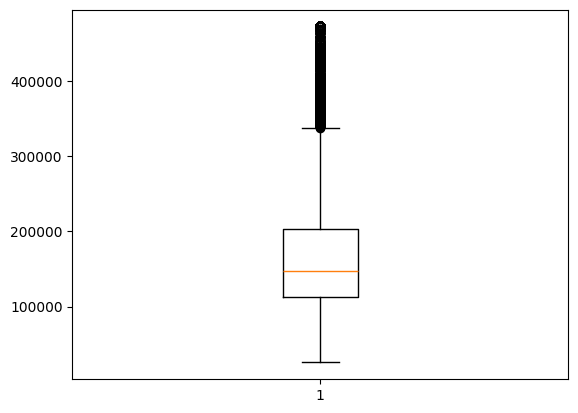

In [10]:
plt.boxplot(df_clean["AMT_INCOME_TOTAL"])
plt.show()

In [14]:
df_clean[df_clean['AMT_INCOME_TOTAL'] > 320000]['AMT_INCOME_TOTAL']

7         360000.0
22        450000.0
33        360000.0
49        360000.0
51        472500.0
            ...   
307460    382500.0
307477    360000.0
307484    472500.0
307492    472500.0
307496    360000.0
Name: AMT_INCOME_TOTAL, Length: 16141, dtype: float64

(array([4.3600e+02, 1.0300e+03, 3.2230e+03, 4.0250e+03, 1.2744e+04,
        5.8880e+03, 8.0390e+03, 2.4592e+04, 7.3990e+03, 3.3325e+04,
        6.6710e+03, 6.2460e+03, 3.6846e+04, 4.8770e+03, 2.7752e+04,
        3.9820e+03, 3.7220e+03, 2.5407e+04, 2.9230e+03, 1.6875e+04,
        1.7470e+03, 1.9040e+03, 2.1042e+04, 1.2170e+03, 5.8080e+03,
        1.0610e+03, 7.1800e+02, 1.0966e+04, 5.5600e+02, 3.6040e+03,
        3.5300e+02, 4.4200e+02, 5.9480e+03, 2.3800e+02, 1.8680e+03,
        1.5900e+02, 2.4400e+02, 4.1670e+03, 1.3300e+02, 1.0410e+03,
        1.6700e+02, 1.0800e+02, 1.6790e+03, 5.8000e+01, 4.9400e+02,
        7.5000e+01, 1.3400e+02, 2.4450e+03, 2.2000e+01, 3.1070e+03]),
 array([ 25650.,  34587.,  43524.,  52461.,  61398.,  70335.,  79272.,
         88209.,  97146., 106083., 115020., 123957., 132894., 141831.,
        150768., 159705., 168642., 177579., 186516., 195453., 204390.,
        213327., 222264., 231201., 240138., 249075., 258012., 266949.,
        275886., 284823., 293760.,

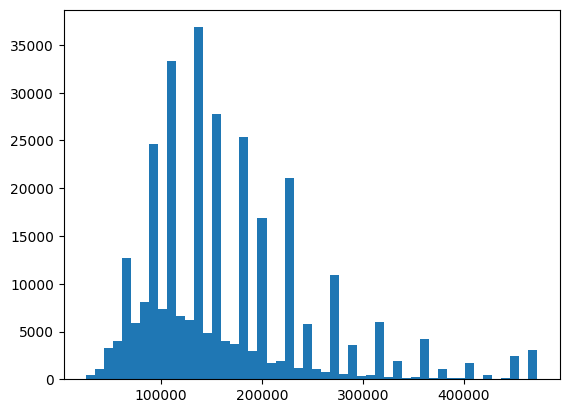

In [11]:
plt.hist(df_clean["AMT_INCOME_TOTAL"], bins=50)

In [ ]:
numerical_cols   = df_clean.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = [c for c in numerical_cols if c != "TARGET"]

In [16]:
numerical_cols

['SK_ID_CURR',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 '

In [ ]:
# ─────────────────────────────────────────────────────────────
# 3E. MISSING VALUE IMPUTATION
# STRATEGY:
#   Numerical   → median  (robust to skew) + missing flag column
#   Categorical → mode    (most frequent)  + missing flag column
# WHY ADD FLAG: The fact that a value is missing is itself
#   a signal. E.g. missing OWN_CAR_AGE likely means no car.
#   The flag captures this without losing the imputed value.
# ─────────────────────────────────────────────────────────────

print("\n[3E] MISSING VALUE IMPUTATION")
print("-" * 40)

# Refresh column lists after adding YEARS_ columns
numerical_cols   = df_clean.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = [c for c in numerical_cols if c != "TARGET"]

missing_num  = [c for c in numerical_cols   if df_clean[c].isnull().any()]
missing_cat  = [c for c in categorical_cols if df_clean[c].isnull().any()]

print(f"  Numerical columns with missing   : {len(missing_num)}")
print(f"  Categorical columns with missing : {len(missing_cat)}")

# -- Numerical imputation
imputation_values = {}   # store medians for use on test set later

for col in missing_num:
    median_val = df_clean[col].median()
    imputation_values[col] = median_val

    # Add missing flag BEFORE filling
    df_clean[col] = df_clean[col].fillna(median_val)

print(f"\n  Numerical: imputed {len(missing_num)} columns with median ")

# -- Categorical imputation
for col in missing_cat:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

print(f"  Categorical: imputed {len(missing_cat)} columns with mode")


[3E] MISSING VALUE IMPUTATION
----------------------------------------
  Numerical columns with missing   : 62
  Categorical columns with missing : 6

  Numerical: imputed 62 columns with median + added _MISSING flag
  Categorical: imputed 6 columns with mode + added _MISSING flag


In [29]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307507 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to YEARS_ID_PUBLISH
dtypes: float64(68), int64(38), object(16)
memory usage: 288.6+ MB


In [30]:
df_clean.isnull().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_YEAR    0
AGE_YEARS                     0
YEARS_EMPLOYED                0
YEARS_REGISTRATION            0
YEARS_ID_PUBLISH              0
Length: 122, dtype: int64

In [31]:
df_clean.shape

(307507, 122)

In [32]:
df_clean.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,1.745205,9.994521,5.808219
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,3.254795,3.249315,0.797260
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,52.180822,0.616438,11.671233,6.934247
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,1.0,52.068493,8.326027,26.939726,6.676712
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,54.608219,8.323288,11.810959,9.473973


In [33]:
# ─────────────────────────────────────────────────────────────
# 3F. ENCODE CATEGORICAL VARIABLES
# WHY: ML models need numbers, not text.
#      Label encoding for binary columns (Y/N, M/F).
#      One-hot encoding for multi-class columns.
# ─────────────────────────────────────────────────────────────

print("\n[3F] ENCODING CATEGORICAL VARIABLES")
print("-" * 40)

# Binary columns — label encode directly
binary_cols = [c for c in categorical_cols if df_clean[c].nunique() <= 2]
for col in binary_cols:
    df_clean[col] = pd.factorize(df_clean[col])[0]
    
print(f"  Label encoded {len(binary_cols)} binary columns")

# Multi-class columns — one-hot encode
multi_cols = [c for c in categorical_cols if df_clean[c].nunique() > 2]
before_cols = df_clean.shape[1]
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)
after_cols = df_clean.shape[1]

print(f"  One-hot encoded {len(multi_cols)} multi-class columns")
print(f"  Columns before encoding: {before_cols}")
print(f"  Columns after encoding : {after_cols}")


[3F] ENCODING CATEGORICAL VARIABLES
----------------------------------------
  Label encoded 5 binary columns
  One-hot encoded 11 multi-class columns
  Columns before encoding: 122
  Columns after encoding : 229



[3G] FINAL VALIDATION
----------------------------------------
  Final shape     : 307,507 rows × 229 cols
  Remaining nulls : 0
  Target balance  : 8.07% default rate


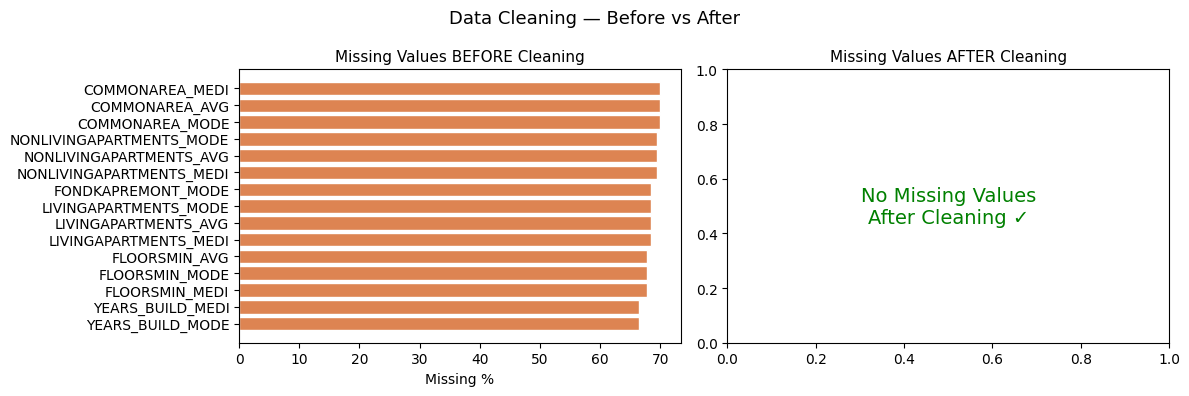


  Chart saved: cleaning_before_after.png


In [34]:
# ─────────────────────────────────────────────────────────────
# 3G. FINAL VALIDATION
# ─────────────────────────────────────────────────────────────

print("\n[3G] FINAL VALIDATION")
print("-" * 40)

remaining_missing = df_clean.isnull().sum().sum()
print(f"  Final shape     : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
print(f"  Remaining nulls : {remaining_missing}")
print(f"  Target balance  : {df_clean['TARGET'].mean()*100:.2f}% default rate")

# Quick before/after chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Missing values before
missing_before = df.isnull().mean().sort_values(ascending=False).head(15) * 100
axes[0].barh(missing_before.index[::-1], missing_before.values[::-1],
             color="#DD8452", edgecolor="white")
axes[0].set_title("Missing Values BEFORE Cleaning", fontsize=11)
axes[0].set_xlabel("Missing %")

# Missing values after
missing_after = df_clean.isnull().mean().sort_values(ascending=False).head(15) * 100
if missing_after.sum() == 0:
    axes[1].text(0.5, 0.5, "No Missing Values\nAfter Cleaning ✓",
                 ha="center", va="center", fontsize=14,
                 color="green", transform=axes[1].transAxes)
    axes[1].set_title("Missing Values AFTER Cleaning", fontsize=11)
else:
    axes[1].barh(missing_after.index[::-1], missing_after.values[::-1],
                 color="#4C72B0", edgecolor="white")
    axes[1].set_title("Missing Values AFTER Cleaning", fontsize=11)
    axes[1].set_xlabel("Missing %")

plt.suptitle("Data Cleaning — Before vs After", fontsize=13)
plt.tight_layout()
plt.savefig("cleaning_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: cleaning_before_after.png")

In [ ]:
print("""
=============================================================
STEP 3 SUMMARY — CLEANING DECISIONS
=============================================================

1. Dropped 4 rows with XNA gender (too few to impute)
2. Fixed DAYS_EMPLOYED=365243 → NaN (was a known placeholder)
3. Converted all DAYS_ columns to positive YEARS_ columns
4. Capped outliers at 99th percentile (winsorization)
5. Imputed numerical NaN → median + added _MISSING flag
6. Imputed categorical NaN → mode + added _MISSING flag
7. Label encoded binary columns (2 unique values)
8. One-hot encoded multi-class categorical columns

KEY TRADE-OFF:
  Median imputation is conservative — it shrinks variance.
  The _MISSING flag compensates by letting the model learn
  that missingness itself carries predictive signal.
=============================================================
""")

In [35]:
# Clean column names — remove special characters that break LightGBM
df_clean.columns = (
    df_clean.columns
     .str.replace(r"[\[\]{}<>(),:\"']", "_", regex=True)
     .str.replace(r"\s+", "_", regex=True)
     .str.strip("_")
)
print(f"  Column names cleaned — special characters removed")
print("[STEP 3 COMPLETE]")
print(f"  df_clean is ready: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")

  Column names cleaned — special characters removed
[STEP 3 COMPLETE]
  df_clean is ready: 307,507 rows × 229 cols


In [36]:
df_clean.to_csv("D:\\home-credit-default-risk\\data\\processed\\application_train_cleaned.csv", index=False)